## Section 0 — Setup & Imports

In [4]:
#  Standard library 
import sys
import os
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

#  Add src/ to Python path 
project_root = Path().resolve().parents[1]
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

#  Data manipulation 
import pandas as pd
import numpy as np

#  Change-point detection 
# ruptures implements the PELT algorithm — Pruned Exact Linear Time
# It finds points in a time series where the statistical properties
# change significantly — e.g. where sales momentum shifted
import ruptures as rpt

#  Visualisation 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#  Shared utilities 
from utils.helpers import set_style, save_figure, start_logging
set_style()
log = start_logging(project_root, '03_01_feature_engineering')

print('All imports successful ')
print(f'Project root: {project_root}')
print(f'ruptures version: {rpt.__version__}')

Logging started — 2026-04-24 11:05:19.862652
Log: /Users/seleteakpotosu-nartey/Downloads/Data Stuff/Gamezone/gamezone-analytics/logs/03_01_feature_engineering.txt
All imports successful 
Project root: /Users/seleteakpotosu-nartey/Downloads/Data Stuff/Gamezone/gamezone-analytics
ruptures version: 1.1.10


## Section 1 — Load & Aggregate to Time Series

In [5]:
processed_path = project_root / 'data' / 'processed'

df_raw = pd.read_csv(
    processed_path / 'orders_clean_master.csv',
    parse_dates=['PURCHASE_TS', 'SHIP_TS']
)
df = df_raw.copy()

# Filter: exclude $0 prices and records with no valid purchase date
df = df[(df['USD_PRICE'] > 0) & (df['PURCHASE_TS'].notna())].copy()

# Extract date only (strip time component)
df['date'] = df['PURCHASE_TS'].dt.date
df['date'] = pd.to_datetime(df['date'])

print(f'Orders loaded:    {len(df):,}')
print(f'Date range:       {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Unique dates:     {df["date"].nunique():,}')
print(f'Unique products:  {df["PRODUCT_NAME"].nunique()}')

Orders loaded:    14,954
Date range:       2019-01-01 → 2021-02-28
Unique dates:     767
Unique products:  8


In [6]:
log(f'Orders loaded:    {len(df):,}')
log(f'Date range:       {df["date"].min().date()} → {df["date"].max().date()}')
log(f'Unique dates:     {df["date"].nunique():,}')
log(f'Unique products:  {df["PRODUCT_NAME"].nunique()}')

Orders loaded:    14,954
Date range:       2019-01-01 → 2021-02-28
Unique dates:     767
Unique products:  8


In [7]:
#  Daily aggregation 
# Sum revenue and count orders per day
# min_count=1 in sum() ensures days with 0 valid orders return NaN
# rather than 0, so we can identify truly missing days later

daily = df.groupby('date').agg(
    order_count  = ('ORDER_ID',   'count'),
    revenue      = ('USD_PRICE',  'sum'),
    avg_price    = ('USD_PRICE',  'mean'),
    unique_products = ('PRODUCT_NAME', 'nunique')
).reset_index()

# Fill in missing dates with 0 — the time series must be continuous
# A model cannot handle gaps in time
date_range = pd.date_range(start=daily['date'].min(),
                            end=daily['date'].max(), freq='D')
daily = daily.set_index('date').reindex(date_range, fill_value=0).reset_index()
daily.columns = ['date'] + list(daily.columns[1:])

print(f'Daily time series: {len(daily):,} rows')
print(f'Date range: {daily["date"].min().date()} → {daily["date"].max().date()}')
print(f'Zero-revenue days: {(daily["revenue"] == 0).sum()}')
print()
print('Daily revenue statistics:')
print(daily['revenue'].describe().round(2))

Daily time series: 790 rows
Date range: 2019-01-01 → 2021-02-28
Zero-revenue days: 23

Daily revenue statistics:
count      790.00
mean      5375.49
std       4207.80
min          0.00
25%       2092.85
50%       4319.80
75%       7820.10
max      24012.36
Name: revenue, dtype: float64


In [8]:
log(f'Daily time series: {len(daily):,} rows')
log(f'Date range: {daily["date"].min().date()} → {daily["date"].max().date()}')
log(f'Zero-revenue days: {(daily["revenue"] == 0).sum()}')
log()
log('Daily revenue statistics:')
log(daily['revenue'].describe().round(2)) # pyright: ignore[reportArgumentType]

Daily time series: 790 rows
Date range: 2019-01-01 → 2021-02-28
Zero-revenue days: 23

Daily revenue statistics:
count      790.00
mean      5375.49
std       4207.80
min          0.00
25%       2092.85
50%       4319.80
75%       7820.10
max      24012.36
Name: revenue, dtype: float64


In [9]:
#  Weekly aggregation 
# W-MON anchors each week to Monday — consistent with how businesses
# typically report weekly figures

weekly = df.resample('W-MON', on='date').agg(
    order_count  = ('ORDER_ID',   'count'),
    revenue      = ('USD_PRICE',  'sum'),
    avg_price    = ('USD_PRICE',  'mean'),
    unique_customers = ('USER_ID', 'nunique')
).reset_index()

weekly.columns = ['week_start', 'order_count', 'revenue', 'avg_price', 'unique_customers']

# Remove the last week if it is incomplete
# An incomplete week would have artificially low values and distort
# the model's understanding of a normal week
last_date    = df['date'].max()
last_week    = weekly.iloc[-1]['week_start']
days_in_last = (last_date - last_week).days + 1
if days_in_last < 7:
    weekly = weekly.iloc[:-1].copy()
    print(f'Removed incomplete last week ({days_in_last} days)')

print(f'Weekly time series: {len(weekly):,} rows')
print(f'Date range: {weekly["week_start"].min().date()} → {weekly["week_start"].max().date()}')
print()
print('Weekly revenue statistics:')
print(weekly['revenue'].describe().round(2))

Removed incomplete last week (0 days)
Weekly time series: 112 rows
Date range: 2019-01-07 → 2021-02-22

Weekly revenue statistics:
count       112.00
mean      37870.90
std       25286.11
min           0.00
25%       18031.23
50%       28497.40
75%       57980.51
max      122738.29
Name: revenue, dtype: float64


In [10]:
log(f'Weekly time series: {len(weekly):,} rows')
log(f'Date range: {weekly["week_start"].min().date()} → {weekly["week_start"].max().date()}')
log()
log('Weekly revenue statistics:')
log(weekly['revenue'].describe().round(2)) # pyright: ignore[reportArgumentType]

Weekly time series: 112 rows
Date range: 2019-01-07 → 2021-02-22

Weekly revenue statistics:
count       112.00
mean      37870.90
std       25286.11
min           0.00
25%       18031.23
50%       28497.40
75%       57980.51
max      122738.29
Name: revenue, dtype: float64


## Section 2 — Calendar Features

In [11]:
def add_calendar_features(df_ts, date_col):
    """
    Add calendar-based features to a time series DataFrame.
    Works on both daily and weekly DataFrames.
    """
    df_ts = df_ts.copy()
    dt = df_ts[date_col]

    df_ts['day_of_week']  = dt.dt.dayofweek        # 0=Monday, 6=Sunday
    df_ts['day_of_month'] = dt.dt.day
    df_ts['month']        = dt.dt.month
    df_ts['quarter']      = dt.dt.quarter
    df_ts['year']         = dt.dt.year
    df_ts['week_of_year'] = dt.dt.isocalendar().week.astype(int)

    # Binary flags — often more useful than the raw number
    df_ts['is_weekend']   = (dt.dt.dayofweek >= 5).astype(int)
    df_ts['is_month_end'] = dt.dt.is_month_end.astype(int)
    df_ts['is_q4']        = (dt.dt.quarter == 4).astype(int)  # gaming peaks in Q4

    # Cyclical encoding for month and day_of_week
    # Why cyclical? December (12) and January (1) are adjacent in time
    # but far apart numerically. Sine/cosine encoding makes 12 and 1
    # close to each other in feature space, which helps models learn
    # seasonal patterns correctly
    df_ts['month_sin'] = np.sin(2 * np.pi * df_ts['month'] / 12)
    df_ts['month_cos'] = np.cos(2 * np.pi * df_ts['month'] / 12)
    df_ts['dow_sin']   = np.sin(2 * np.pi * df_ts['day_of_week'] / 7)
    df_ts['dow_cos']   = np.cos(2 * np.pi * df_ts['day_of_week'] / 7)

    return df_ts

daily  = add_calendar_features(daily,  'date')
weekly = add_calendar_features(weekly, 'week_start')

print('Calendar features added ')
print(f'New columns: {[c for c in daily.columns if c not in ["date","order_count","revenue","avg_price","unique_products"]]}')

Calendar features added 
New columns: ['day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'week_of_year', 'is_weekend', 'is_month_end', 'is_q4', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']


In [12]:
log('Calendar features added ')
log(f'New columns: {[c for c in daily.columns if c not in ["date","order_count","revenue","avg_price","unique_products"]]}')

Calendar features added 
New columns: ['day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'week_of_year', 'is_weekend', 'is_month_end', 'is_q4', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']


## Section 3 — Lag Features

In [13]:
def add_lag_features(df_ts, target_col, lags):
    """
    Add lag features for a target column.

    Parameters
    ----------
    df_ts      : DataFrame with time series data
    target_col : column to lag (e.g. 'revenue')
    lags       : list of lag periods (e.g. [1, 2, 4, 8] for weeks)
    """
    df_ts = df_ts.copy()
    for lag in lags:
        # .shift(lag) moves values forward by lag periods
        # so lag_1 at row N contains the value from row N-1
        df_ts[f'{target_col}_lag_{lag}'] = df_ts[target_col].shift(lag)
    return df_ts

# Weekly lags: 1 week, 2 weeks, 4 weeks (1 month), 8 weeks (2 months)
weekly = add_lag_features(weekly, 'revenue',     lags=[1, 2, 4, 8])
weekly = add_lag_features(weekly, 'order_count', lags=[1, 2, 4])

# Daily lags: 7 days (same day last week), 14 days, 28 days
daily  = add_lag_features(daily,  'revenue',     lags=[7, 14, 28])
daily  = add_lag_features(daily,  'order_count', lags=[7, 14])

print('Lag features added ')
print(f'Weekly lag columns: {[c for c in weekly.columns if "lag" in c]}')
print(f'Daily lag columns:  {[c for c in daily.columns if "lag" in c]}')
print()
# Lag features create NaN at the start of the series
# (there is no "8 weeks ago" for the first 8 rows)
print(f'Weekly rows with any NaN after lagging: {weekly.isna().any(axis=1).sum()}')
print(f'Daily rows with any NaN after lagging:  {daily.isna().any(axis=1).sum()}')

Lag features added 
Weekly lag columns: ['revenue_lag_1', 'revenue_lag_2', 'revenue_lag_4', 'revenue_lag_8', 'order_count_lag_1', 'order_count_lag_2', 'order_count_lag_4']
Daily lag columns:  ['revenue_lag_7', 'revenue_lag_14', 'revenue_lag_28', 'order_count_lag_7', 'order_count_lag_14']

Weekly rows with any NaN after lagging: 9
Daily rows with any NaN after lagging:  28


In [14]:
log('Lag features added ')
log(f'Weekly lag columns: {[c for c in weekly.columns if "lag" in c]}')
log(f'Daily lag columns:  {[c for c in daily.columns if "lag" in c]}')
log()
# Lag features create NaN at the start of the series
# (there is no "8 weeks ago" for the first 8 rows)
log(f'Weekly rows with any NaN after lagging: {weekly.isna().any(axis=1).sum()}')
log(f'Daily rows with any NaN after lagging:  {daily.isna().any(axis=1).sum()}')

Lag features added 
Weekly lag columns: ['revenue_lag_1', 'revenue_lag_2', 'revenue_lag_4', 'revenue_lag_8', 'order_count_lag_1', 'order_count_lag_2', 'order_count_lag_4']
Daily lag columns:  ['revenue_lag_7', 'revenue_lag_14', 'revenue_lag_28', 'order_count_lag_7', 'order_count_lag_14']

Weekly rows with any NaN after lagging: 9
Daily rows with any NaN after lagging:  28


## Section 4 — Rolling Average Features

In [15]:
def add_rolling_features(df_ts, target_col, windows):
    """
    Add rolling mean and standard deviation features.

    Standard deviation captures volatility — a period of high
    revenue variance may predict different future behaviour
    than a period of stable revenue.
    """
    df_ts = df_ts.copy()
    for window in windows:
        # .shift(1) before rolling ensures we don't include the current
        # row in its own rolling average — that would be data leakage
        shifted = df_ts[target_col].shift(1)
        df_ts[f'{target_col}_roll_mean_{window}'] = (
            shifted.rolling(window, min_periods=1).mean()
        )
        df_ts[f'{target_col}_roll_std_{window}']  = (
            shifted.rolling(window, min_periods=1).std()
        )
    return df_ts

# Weekly windows: 4 weeks (1 month), 8 weeks (2 months), 13 weeks (quarter)
weekly = add_rolling_features(weekly, 'revenue',     windows=[4, 8, 13])
weekly = add_rolling_features(weekly, 'order_count', windows=[4, 8])

# Daily windows: 7 days, 30 days
daily  = add_rolling_features(daily,  'revenue',     windows=[7, 30])

print('Rolling features added ')
print(f'Weekly rolling columns: {[c for c in weekly.columns if "roll" in c]}')
print()
print('Sample of weekly feature matrix (first 5 rows with lag and rolling):')
feature_cols = ['week_start', 'revenue', 'revenue_lag_1', 'revenue_roll_mean_4']
print(weekly[feature_cols].head(10).to_string(index=False))

Rolling features added 
Weekly rolling columns: ['revenue_roll_mean_4', 'revenue_roll_std_4', 'revenue_roll_mean_8', 'revenue_roll_std_8', 'revenue_roll_mean_13', 'revenue_roll_std_13', 'order_count_roll_mean_4', 'order_count_roll_std_4', 'order_count_roll_mean_8', 'order_count_roll_std_8']

Sample of weekly feature matrix (first 5 rows with lag and rolling):
week_start  revenue  revenue_lag_1  revenue_roll_mean_4
2019-01-07 13570.67            NaN                  NaN
2019-01-14  9403.49       13570.67           13570.6700
2019-01-21 20334.95        9403.49           11487.0800
2019-01-28 15230.66       20334.95           14436.3700
2019-02-04  7146.42       15230.66           14634.9425
2019-02-11 10361.19        7146.42           13028.8800
2019-02-18 15178.47       10361.19           13268.3050
2019-02-25 16962.34       15178.47           11979.1850
2019-03-04 19523.73       16962.34           12412.1050
2019-03-11 21879.41       19523.73           15506.4325


In [16]:
log('Rolling features added ')
log(f'Weekly rolling columns: {[c for c in weekly.columns if "roll" in c]}')
log()
log('Sample of weekly feature matrix (first 5 rows with lag and rolling):')
feature_cols = ['week_start', 'revenue', 'revenue_lag_1', 'revenue_roll_mean_4']
log(weekly[feature_cols].head(10).to_string(index=False))

Rolling features added 
Weekly rolling columns: ['revenue_roll_mean_4', 'revenue_roll_std_4', 'revenue_roll_mean_8', 'revenue_roll_std_8', 'revenue_roll_mean_13', 'revenue_roll_std_13', 'order_count_roll_mean_4', 'order_count_roll_std_4', 'order_count_roll_mean_8', 'order_count_roll_std_8']

Sample of weekly feature matrix (first 5 rows with lag and rolling):
week_start  revenue  revenue_lag_1  revenue_roll_mean_4
2019-01-07 13570.67            NaN                  NaN
2019-01-14  9403.49       13570.67           13570.6700
2019-01-21 20334.95        9403.49           11487.0800
2019-01-28 15230.66       20334.95           14436.3700
2019-02-04  7146.42       15230.66           14634.9425
2019-02-11 10361.19        7146.42           13028.8800
2019-02-18 15178.47       10361.19           13268.3050
2019-02-25 16962.34       15178.47           11979.1850
2019-03-04 19523.73       16962.34           12412.1050
2019-03-11 21879.41       19523.73           15506.4325


## Section 5 — Change-Point Detection (PELT)

In [17]:
# Run PELT change-point detection on weekly revenue
# model='rbf' uses a radial basis function cost — good for detecting
# changes in both mean and variance

revenue_signal = weekly['revenue'].values

algo = rpt.Pelt(model='rbf').fit(revenue_signal)

# pen controls sensitivity:
# too low  = detects noise as change-points
# too high = misses real structural changes
# We start at pen=10 and review the results visually
change_points = algo.predict(pen=10)

# PELT returns indices — convert to actual dates
# The last element is always len(signal) which marks the series end
cp_dates = [
    weekly.iloc[cp - 1]['week_start']
    for cp in change_points[:-1]  # exclude the final boundary
]

print(f'Change-points detected: {len(cp_dates)}')
for i, date in enumerate(cp_dates, 1):
    print(f'  Change-point {i}: {date.date()}')

# Add a regime feature — which regime is each week in?
# Regime 0 = before first change-point, Regime 1 = after, etc.
weekly['regime'] = 0
for i, cp_idx in enumerate(change_points[:-1], 1):
    weekly.loc[cp_idx:, 'regime'] = i

print(f'\nRegime distribution:')
print(weekly['regime'].value_counts().sort_index())

Change-points detected: 1
  Change-point 1: 2020-02-24

Regime distribution:
regime
0    60
1    52
Name: count, dtype: int64


In [18]:
log(f'\nRegime distribution:')
log(weekly['regime'].value_counts().sort_index()) # pyright: ignore[reportArgumentType]


Regime distribution:
regime
0    60
1    52
Name: count, dtype: int64


## Section 6 — Product Mix Features

In [19]:
# Define high-ticket products based on Project 01 findings
# These are products with median price above $500
high_ticket = [
    'Sony PlayStation 5 Bundle',
    'Lenovo IdeaPad Gaming 3',
    'Acer Nitro V Gaming Laptop'
]

df['is_high_ticket'] = df['PRODUCT_NAME'].isin(high_ticket).astype(int)

# Weekly product mix: proportion of high-ticket orders per week
product_mix = df.resample('W-MON', on='date').agg(
    high_ticket_count = ('is_high_ticket', 'sum'),
    total_orders      = ('ORDER_ID', 'count')
).reset_index()
product_mix.columns = ['week_start', 'high_ticket_count', 'total_orders']
product_mix['high_ticket_pct'] = (
    product_mix['high_ticket_count'] / product_mix['total_orders']
).fillna(0).round(4)

# Merge into weekly feature table
weekly = weekly.merge(
    product_mix[['week_start', 'high_ticket_pct', 'high_ticket_count']],
    on='week_start', how='left'
)

print('Product mix features added ')
print(f'Avg high-ticket % per week: {weekly["high_ticket_pct"].mean():.1%}')
print(f'Max high-ticket % in a week: {weekly["high_ticket_pct"].max():.1%}')
print(f'Min high-ticket % in a week: {weekly["high_ticket_pct"].min():.1%}')

Product mix features added 
Avg high-ticket % per week: 7.3%
Max high-ticket % in a week: 15.8%
Min high-ticket % in a week: 0.0%


In [20]:
log('Product mix features added ')
log(f'Avg high-ticket % per week: {weekly["high_ticket_pct"].mean():.1%}')
log(f'Max high-ticket % in a week: {weekly["high_ticket_pct"].max():.1%}')
log(f'Min high-ticket % in a week: {weekly["high_ticket_pct"].min():.1%}')

Product mix features added 
Avg high-ticket % per week: 7.3%
Max high-ticket % in a week: 15.8%
Min high-ticket % in a week: 0.0%


---
## Section 7 — Visualisations

Figure saved → reports/figures/03_01_weekly_revenue_changepoints.png


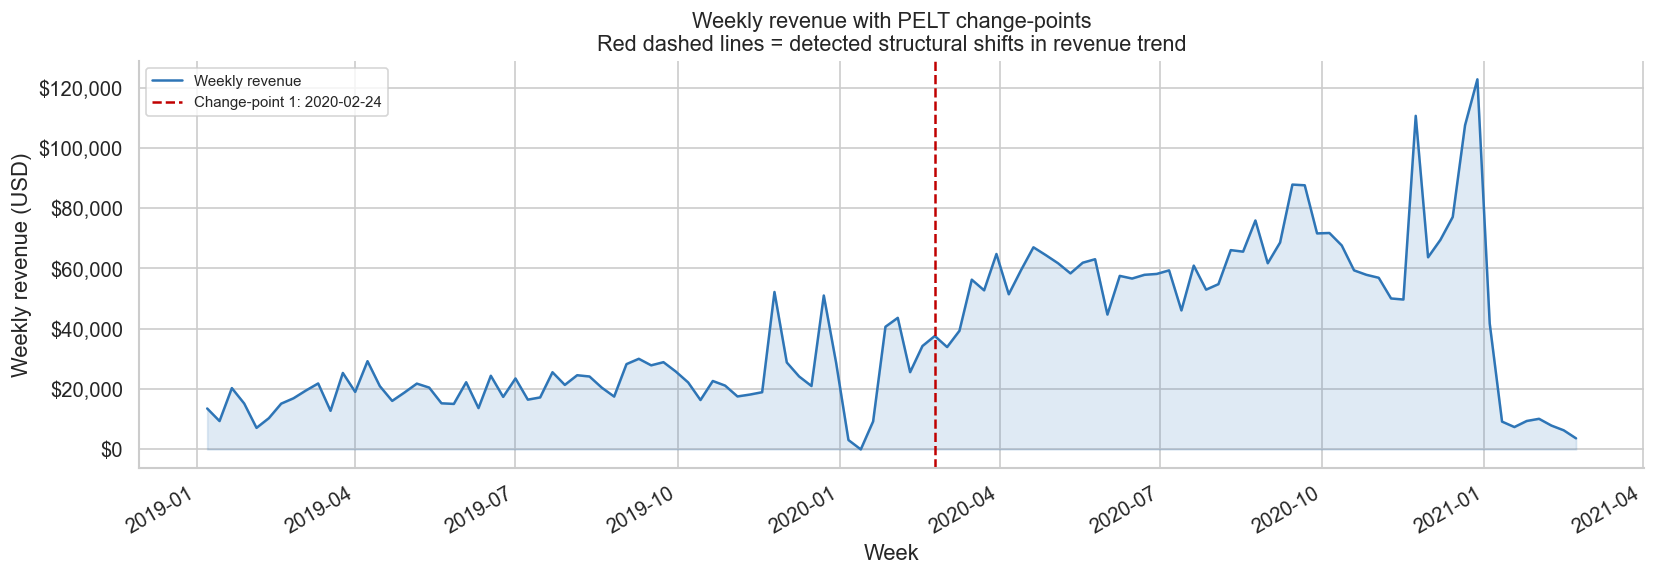

In [21]:
#  Chart 1: Weekly revenue with change-points 
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(weekly['week_start'], weekly['revenue'],
        color='#2E75B6', linewidth=1.5, label='Weekly revenue')
ax.fill_between(weekly['week_start'], weekly['revenue'],
                alpha=0.15, color='#2E75B6')

# Mark change-points as vertical lines
for i, cp_date in enumerate(cp_dates):
    ax.axvline(cp_date, color='#C00000', linestyle='--',
               linewidth=1.5, label=f'Change-point {i+1}: {cp_date.date()}')

ax.set_title('Weekly revenue with PELT change-points\n'
             'Red dashed lines = detected structural shifts in revenue trend',
             fontsize=13, fontweight='medium')
ax.set_xlabel('Week')
ax.set_ylabel('Weekly revenue (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=9)
plt.xticks(rotation=30, ha='right')

save_figure(fig, '03_01_weekly_revenue_changepoints.png')
plt.show()

Figure saved → reports/figures/03_01_lag_feature_correlations.png


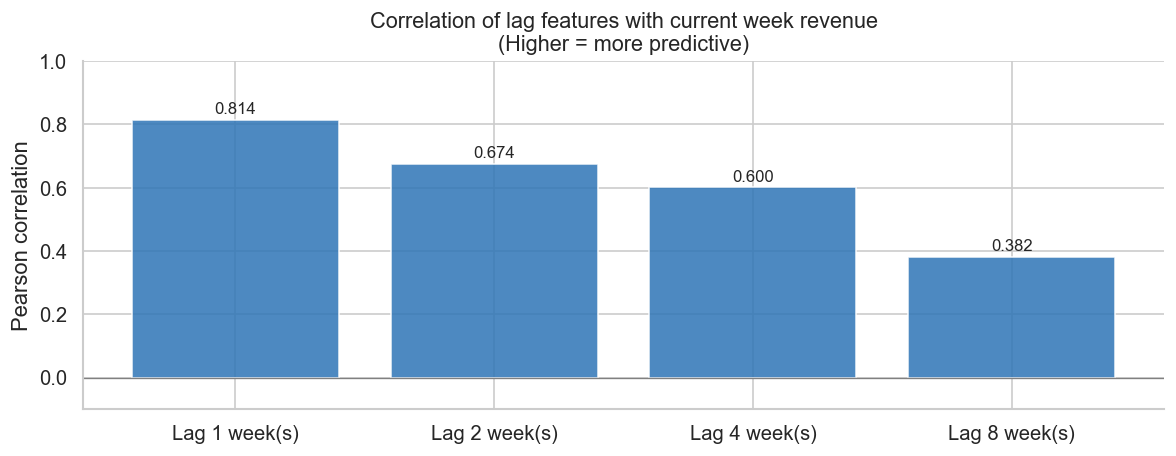

In [22]:
#  Chart 2: Lag feature correlation with revenue 
# How well does each lag predict this week's revenue?
# A high correlation means the lag is a useful feature

lag_cols = [c for c in weekly.columns if 'revenue_lag' in c]
weekly_clean = weekly.dropna(subset=lag_cols + ['revenue'])

correlations = {
    col: weekly_clean['revenue'].corr(weekly_clean[col])
    for col in lag_cols
}

fig, ax = plt.subplots(figsize=(10, 4))
labels = [c.replace('revenue_lag_', 'Lag ') + ' week(s)' for c in lag_cols]
values = list(correlations.values())
colors = ['#2E75B6' if v > 0 else '#C00000' for v in values]

bars = ax.bar(labels, values, color=colors, alpha=0.85)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)

ax.axhline(0, color='grey', linewidth=0.8)
ax.set_title('Correlation of lag features with current week revenue\n'
             '(Higher = more predictive)',
             fontsize=13, fontweight='medium')
ax.set_ylabel('Pearson correlation')
ax.set_ylim(-0.1, 1.0)

save_figure(fig, '03_01_lag_feature_correlations.png')
plt.show()

Figure saved → reports/figures/03_01_revenue_by_day_of_week.png


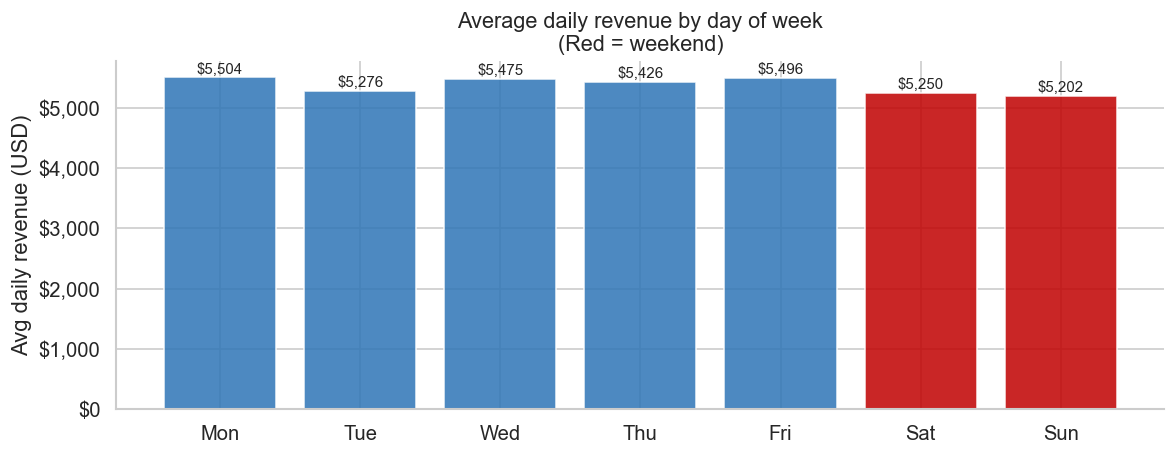

In [23]:
#  Chart 3: Revenue by day of week (daily data) 
# Is there a day-of-week pattern in orders?
# Gaming purchases may peak on weekends or Fridays

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_revenue = daily.groupby('day_of_week')['revenue'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#C00000' if d >= 5 else '#2E75B6' for d in dow_revenue.index]
bars = ax.bar([day_names[d] for d in dow_revenue.index],
              dow_revenue.values, color=colors, alpha=0.85) # pyright: ignore[reportArgumentType]

for bar, val in zip(bars, dow_revenue.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Average daily revenue by day of week\n'
             '(Red = weekend)',
             fontsize=13, fontweight='medium')
ax.set_ylabel('Avg daily revenue (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

save_figure(fig, '03_01_revenue_by_day_of_week.png')
plt.show()

Figure saved → reports/figures/03_01_revenue_by_month.png


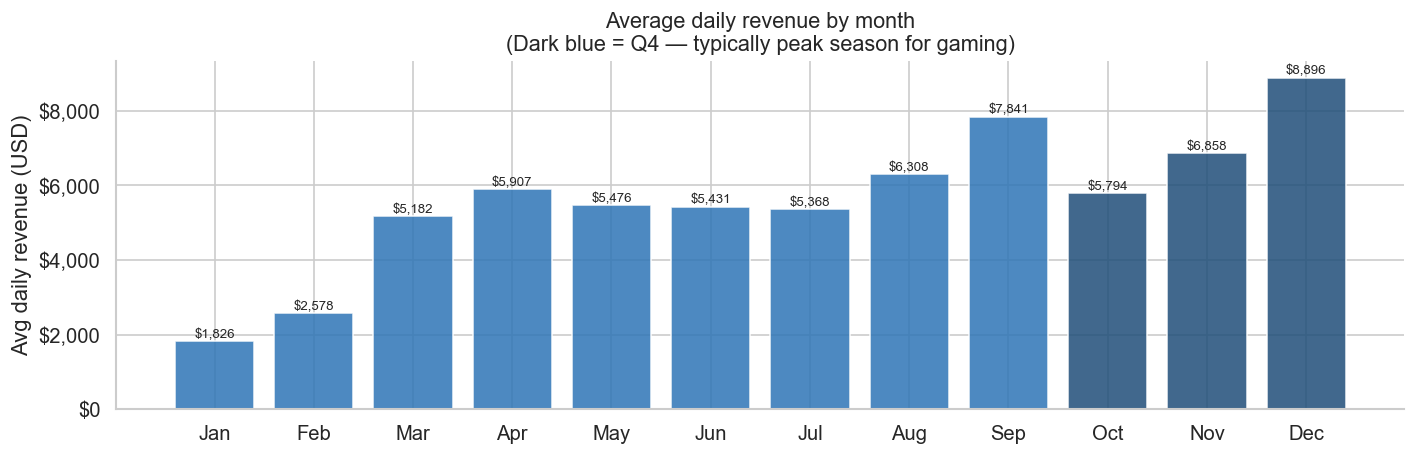

In [24]:
#  Chart 4: Revenue by month 
# Does revenue follow a seasonal pattern?
# Q4 (Oct-Dec) is typically peak for gaming hardware

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
month_revenue = daily.groupby('month')['revenue'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#1F4E79' if m in [10, 11, 12] else '#2E75B6'
          for m in month_revenue.index]
bars = ax.bar([month_names[m-1] for m in month_revenue.index],
              month_revenue.values, color=colors, alpha=0.85) # pyright: ignore[reportArgumentType]

for bar, val in zip(bars, month_revenue.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Average daily revenue by month\n'
             '(Dark blue = Q4 — typically peak season for gaming)',
             fontsize=13, fontweight='medium')
ax.set_ylabel('Avg daily revenue (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

save_figure(fig, '03_01_revenue_by_month.png')
plt.show()

Figure saved → reports/figures/03_01_feature_correlation_heatmap.png


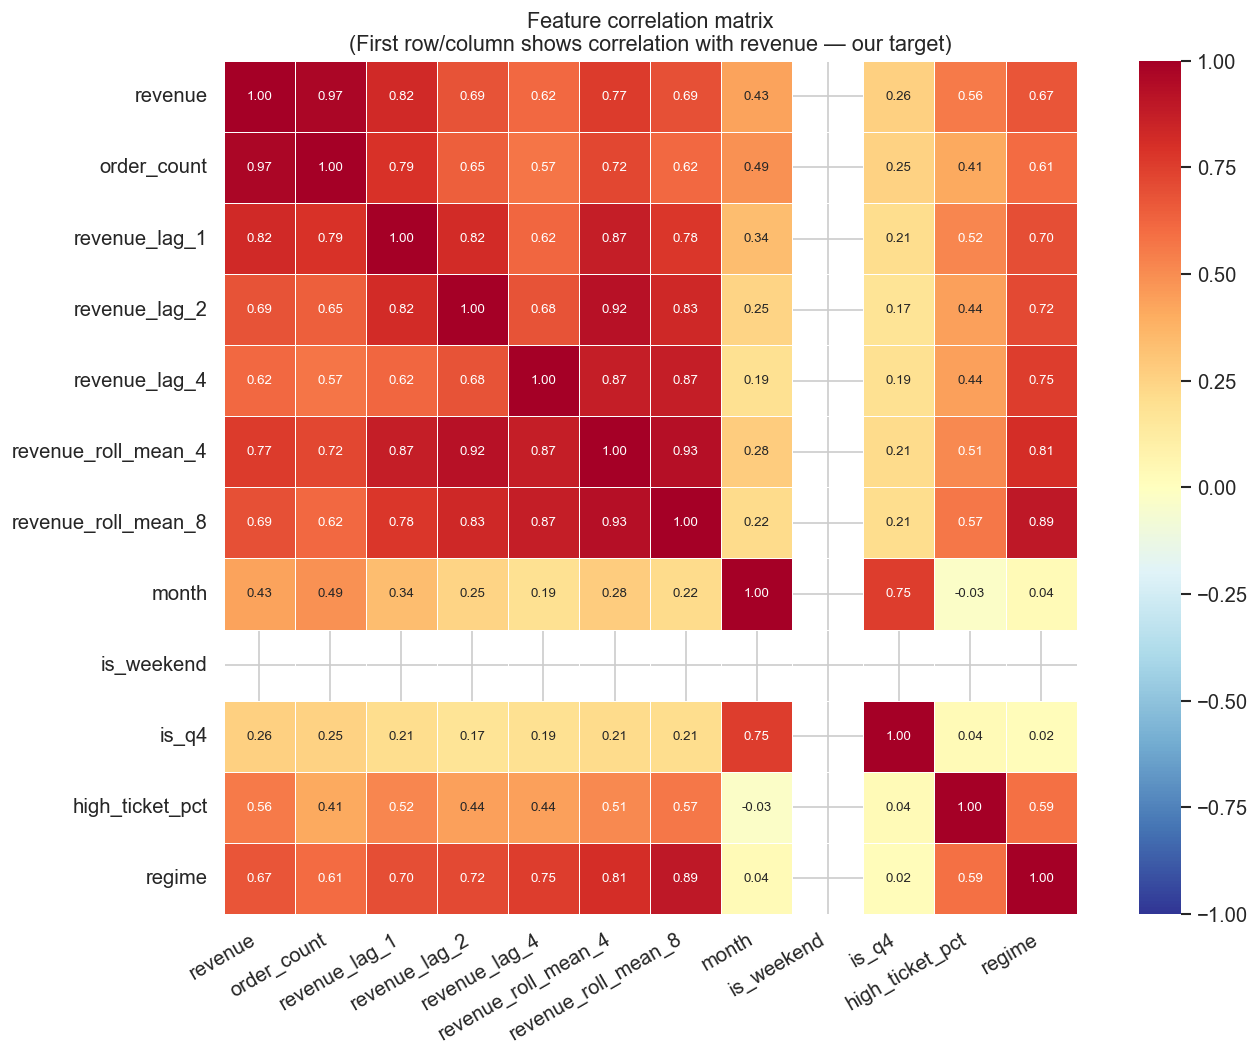

In [25]:
#  Chart 5: Feature correlation heatmap 
# Shows how all engineered features relate to revenue
# and to each other — helps spot redundant features

feature_cols_for_heatmap = [
    'revenue', 'order_count',
    'revenue_lag_1', 'revenue_lag_2', 'revenue_lag_4',
    'revenue_roll_mean_4', 'revenue_roll_mean_8',
    'month', 'is_weekend', 'is_q4',
    'high_ticket_pct', 'regime'
]
available_cols = [c for c in feature_cols_for_heatmap if c in weekly.columns]
corr_matrix    = weekly[available_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, square=True, linewidths=0.5,
    annot_kws={'size': 8}
)
ax.set_title('Feature correlation matrix\n'
             '(First row/column shows correlation with revenue — our target)',
             fontsize=13, fontweight='medium')
plt.xticks(rotation=30, ha='right')

save_figure(fig, '03_01_feature_correlation_heatmap.png')
plt.show()

## Section 8 — Final Feature Matrix & Export

In [26]:
# Final feature matrix summary
print(' Final Weekly Feature Matrix ')
print(f'Total rows before dropping NaN: {len(weekly):,}')

# Drop rows where lag features are NaN
# These are the first few rows that don't have enough history
lag_feature_cols = [c for c in weekly.columns if 'lag' in c]
weekly_clean = weekly.dropna(subset=lag_feature_cols).copy()

print(f'Rows after dropping NaN lags:   {len(weekly_clean):,}')
print(f'Rows dropped:                   {len(weekly) - len(weekly_clean):,}')
print(f'Total features:                 {len(weekly_clean.columns)}')
print(f'\nAll columns:')
for col in weekly_clean.columns:
    print(f'  {col}')

 Final Weekly Feature Matrix 
Total rows before dropping NaN: 112
Rows after dropping NaN lags:   104
Rows dropped:                   8
Total features:                 38

All columns:
  week_start
  order_count
  revenue
  avg_price
  unique_customers
  day_of_week
  day_of_month
  month
  quarter
  year
  week_of_year
  is_weekend
  is_month_end
  is_q4
  month_sin
  month_cos
  dow_sin
  dow_cos
  revenue_lag_1
  revenue_lag_2
  revenue_lag_4
  revenue_lag_8
  order_count_lag_1
  order_count_lag_2
  order_count_lag_4
  revenue_roll_mean_4
  revenue_roll_std_4
  revenue_roll_mean_8
  revenue_roll_std_8
  revenue_roll_mean_13
  revenue_roll_std_13
  order_count_roll_mean_4
  order_count_roll_std_4
  order_count_roll_mean_8
  order_count_roll_std_8
  regime
  high_ticket_pct
  high_ticket_count


In [27]:
os.makedirs(processed_path, exist_ok=True)

#  Output 1: Prophet format (date + revenue only) 
# Prophet requires exactly two columns: 'ds' (date) and 'y' (target)
prophet_df = weekly[['week_start', 'revenue']].copy()
prophet_df.columns = ['ds', 'y']
prophet_df = prophet_df.dropna()

prophet_output = processed_path / 'ts_prophet_weekly.csv'
prophet_df.to_csv(prophet_output, index=False)
print(f'Output 1: ts_prophet_weekly.csv  ({len(prophet_df):,} rows)')

#  Output 2: LightGBM format (full feature matrix) 
lgbm_output = processed_path / 'ts_features_weekly.csv'
weekly_clean.to_csv(lgbm_output, index=False)
print(f'Output 2: ts_features_weekly.csv ({len(weekly_clean):,} rows, {len(weekly_clean.columns)} features)')

#  Output 3: Daily feature matrix
daily_output = processed_path / 'ts_features_daily.csv'
daily.to_csv(daily_output, index=False)
print(f'Output 3: ts_features_daily.csv  ({len(daily):,} rows)') # pyright: ignore[reportArgumentType]
print()
print('Notebook 1 complete')


Output 1: ts_prophet_weekly.csv  (112 rows)
Output 2: ts_features_weekly.csv (104 rows, 38 features)
Output 3: ts_features_daily.csv  (790 rows)

Notebook 1 complete
